### load dataset

In [ ]:
import pandas as pd
import numpy as np

sentiment_df = pd.read_csv("../data/fear_greed_index.csv")
trader_df = pd.read_csv("../data/historical_data.csv")

print(sentiment_df.head())
print(trader_df.head())

    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50 

### Inspect the data

In [3]:
print(sentiment_df.info())
print(trader_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 n

In [ ]:

sentiment_df['date'] = pd.to_datetime(sentiment_df['date'])

sentiment_df['classification'] = (
    sentiment_df['classification']
    .str.strip()
    .str.capitalize()
)

print(sentiment_df['classification'].value_counts())

classification
Fear             781
Greed            633
Extreme fear     508
Neutral          396
Extreme greed    326
Name: count, dtype: int64


In [ ]:
import pandas as pd

trader_df['Timestamp'] = pd.to_datetime(trader_df['Timestamp'])

numeric_cols = [
    'Execution Price',
    'Size Tokens',
    'Size USD',
    'Closed PnL'
]

for col in numeric_cols:
    trader_df[col] = pd.to_numeric(
        trader_df[col],
        errors='coerce'
    )
trader_df = trader_df.dropna(subset=['Closed PnL'])

print(trader_df.head())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec0945

In [ ]:

trader_df['Timestamp IST'] = pd.to_datetime(
    trader_df['Timestamp IST'],
    dayfirst=True,
    errors='coerce'
)

sentiment_df['date'] = pd.to_datetime(
    sentiment_df['date'],
    dayfirst=True,
    errors='coerce'
)

trader_df['Date'] = trader_df['Timestamp IST'].dt.date
sentiment_df['Date'] = sentiment_df['date'].dt.date

In [17]:
merged_df = pd.merge(
    trader_df,
    sentiment_df,
    on='Date',
    how='left'
)

print(merged_df.head())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side       Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY 2024-12-02 22:50:00        0.000000       Buy   
1        16.00    127.68  BUY 2024-12-02 22:50:00      986.524596       Buy   
2       144.09   1150.63  BUY 2024-12-02 22:50:00     1002.518996       Buy   
3       142.98   1142.04  BUY 2024-12-02 22:50:00     1146.558564       Buy   
4         8.73     69.75  BUY 2024-12-02 22:50:00     1289.488521       Buy   

   Closed PnL  ...     Order ID  Crossed       Fee      Trade ID  \
0         0.0  ...  5201

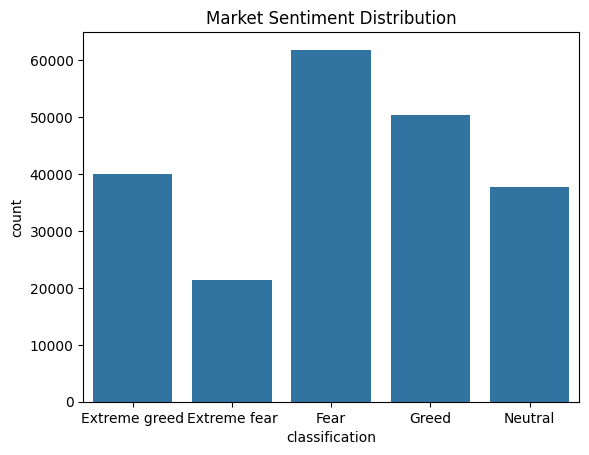

In [24]:

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(
    data=merged_df,
    x='classification'
)

plt.title("Market Sentiment Distribution")
plt.show()

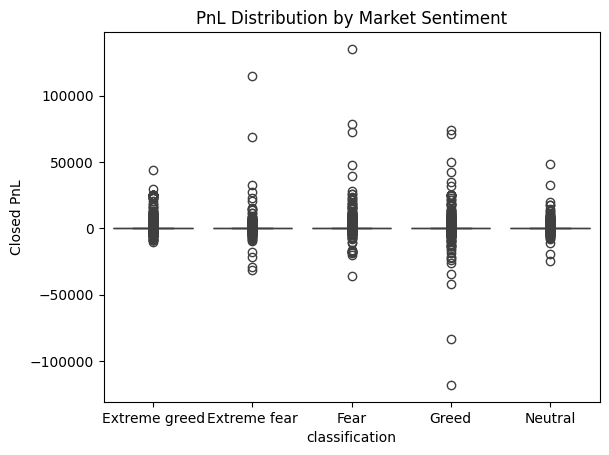

In [26]:
sns.boxplot(
    data=merged_df,
    x='classification',
    y='Closed PnL'
)

plt.title("PnL Distribution by Market Sentiment")
plt.show()

In [28]:
merged_df.groupby('classification')['Size USD'].mean()

classification
Extreme fear     5349.731843
Extreme greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64

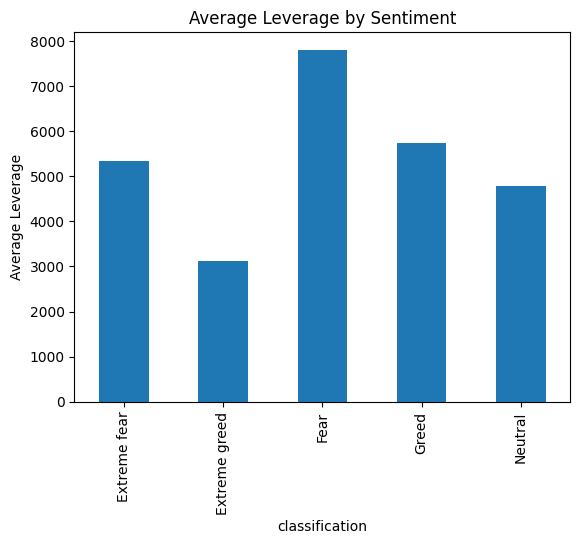

In [29]:
merged_df.groupby('classification')['Size USD'] \
    .mean() \
    .plot(kind='bar')

plt.ylabel("Average Leverage")
plt.title("Average Leverage by Sentiment")
plt.show()

In [31]:
merged_df['is_profit'] = (
    merged_df['Closed PnL'] > 0
).astype(int)

In [33]:
merged_df['s=Side'] = (
    merged_df['Side']
    .str.upper()
)

In [35]:
merged_df['position_value'] = (
    merged_df['Execution Price']
    * merged_df['Size Tokens']
)

In [36]:
win_rate = merged_df.groupby(
    'classification'
)['is_profit'].mean()

print(win_rate)

classification
Extreme fear     0.370607
Extreme greed    0.464943
Fear             0.420768
Greed            0.384828
Neutral          0.396991
Name: is_profit, dtype: float64


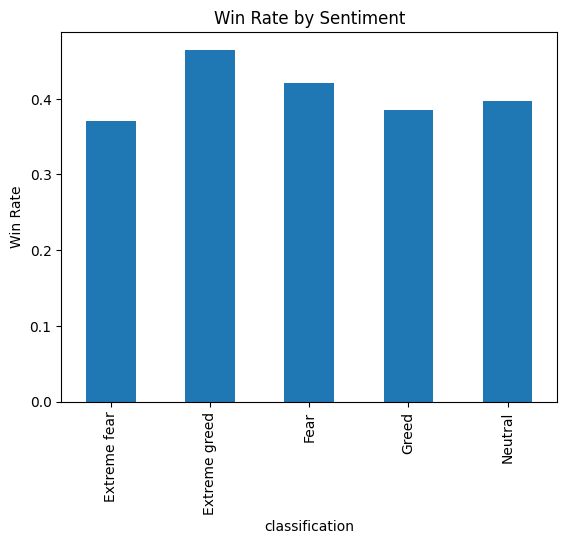

In [37]:
win_rate.plot(kind='bar')

plt.ylabel("Win Rate")
plt.title("Win Rate by Sentiment")
plt.show()